In [12]:
import pandas as pd

df = pd.read_csv("tmdb_5000_movies.csv")

In [17]:
df.shape      # quantas linhas e colunas

(4803, 20)

In [18]:
df.columns    # nome de todas as colunas

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')

In [19]:
df.info()     # tipo de dado de cada coluna

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [30]:
df[["title", "vote_average", "revenue", "release_date"]] # selecionar apenas algumas colunas

,title,vote_average,revenue,release_date
0,Avatar,7.2,2787965087,2009-12-10
1,Pirates of the Caribbean: At World's End,6.9,961000000,2007-05-19
2,Spectre,6.3,880674609,2015-10-26
3,The Dark Knight Rises,7.6,1084939099,2012-07-16
4,John Carter,6.1,284139100,2012-03-07
...,...,...,...,...
4798,El Mariachi,6.6,2040920,1992-09-04
4799,Newlyweds,5.9,0,2011-12-26
4800,"Signed, Sealed, Delivered",7.0,0,2013-10-13
4801,Shanghai Calling,5.7,0,2012-05-03


In [20]:
df.describe() #média, mínimo, máximo e outros dados numéricos

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


In [21]:
filmes_bons = df[df["vote_average"] > 8] #filmes com nota acima de 8
filmes_bons[["title", "vote_average"]]

,title,vote_average
65,The Dark Knight,8.2
95,Interstellar,8.1
96,Inception,8.1
329,The Lord of the Rings: The Return of the King,8.1
662,Fight Club,8.3
690,The Green Mile,8.2
809,Forrest Gump,8.2
1553,Se7en,8.1
1663,Once Upon a Time in America,8.2
1818,Schindler's List,8.3


In [22]:
top10 = df.sort_values("vote_average", ascending=False).head(10) #10 filmes mais bem avaliados
top10[["title", "vote_average", "vote_count"]]

,title,vote_average,vote_count
4662,Little Big Top,10.0,1
3519,Stiff Upper Lips,10.0,1
4045,"Dancer, Texas Pop. 81",10.0,1
4247,Me You and Five Bucks,10.0,2
3992,Sardaarji,9.5,2
2386,One Man's Hero,9.3,2
1881,The Shawshank Redemption,8.5,8205
2970,There Goes My Baby,8.5,2
3337,The Godfather,8.4,5893
2796,The Prisoner of Zenda,8.4,11


In [23]:
mais_ricos = df.sort_values("revenue", ascending=False).head(10) # 10 filmes com maior bilheteria
mais_ricos[["title", "revenue"]]

,title,revenue
0,Avatar,2787965087
25,Titanic,1845034188
16,The Avengers,1519557910
28,Jurassic World,1513528810
44,Furious 7,1506249360
7,Avengers: Age of Ultron,1405403694
124,Frozen,1274219009
31,Iron Man 3,1215439994
546,Minions,1156730962
26,Captain America: Civil War,1153304495


In [24]:
df.isnull().sum() # células vazias existem em cada coluna

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64

In [25]:
df_limpo = df.dropna(subset=["vote_average", "revenue"]) #linhas sem valores nulos
print(f"Antes: {len(df)} linhas")
print(f"Depois: {len(df_limpo)} linhas")

Antes: 4803 linhas
Depois: 4803 linhas


In [27]:
df_limpo = df_limpo[df_limpo["revenue"] > 0] #Remover filmes com bilheteria zero

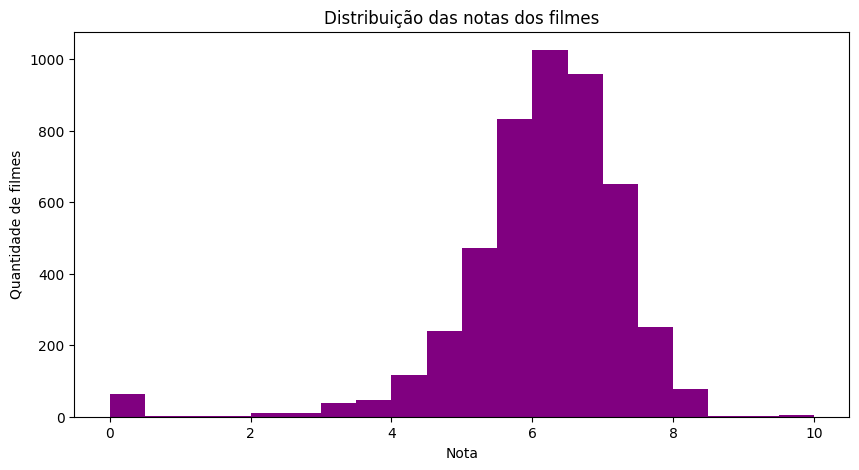

In [34]:
import matplotlib.pyplot as plt #Distribuição das notas em um gráfico

plt.figure(figsize=(10, 5)) #Cria uma figura nova e define o tamanho
plt.hist(df["vote_average"], bins=20, color="purple") #bins=divide o gráfico em "caixinhas", quanto mais, mais detalhado fica 
plt.title("Distribuição das notas dos filmes") #Coloca um título no topo do gráfico
plt.xlabel("Nota") #Legenda do eixo X
plt.ylabel("Quantidade de filmes") #Legenda do eixo Y
plt.show()

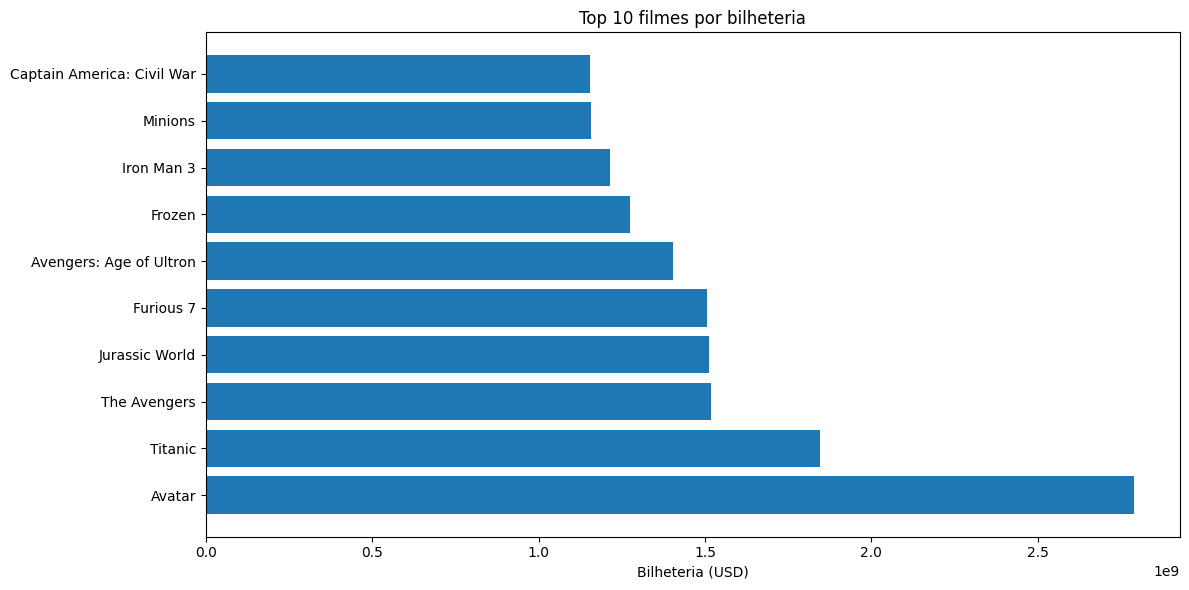

In [37]:
top_bilheteria = df_limpo.sort_values("revenue", ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_bilheteria["title"], top_bilheteria["revenue"])
plt.title("Top 10 filmes por bilheteria")
plt.xlabel("Bilheteria (USD)")
plt.tight_layout() #ajusta automaticamente o espaçamento interno do gráfico
plt.show()

In [38]:
top10 = df.sort_values("vote_average", ascending=False).head(10) #Salvar o top 10 em um arquivo CSV
top10[["title", "vote_average", "revenue"]].to_csv("top10_filmes.csv", index=False)
print("Arquivo salvo")

Arquivo salvo


In [39]:
df_limpo.to_csv("filmes_limpos.csv", index=False) #salvar dataset limpo

In [40]:
plt.savefig("grafico_notas.png", dpi=150, bbox_inches="tight") # salvar gráfico como imagem

<Figure size 640x480 with 0 Axes>